<a href="https://colab.research.google.com/github/meetj6897/Develop-LLM-from-scratch/blob/main/LLM_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

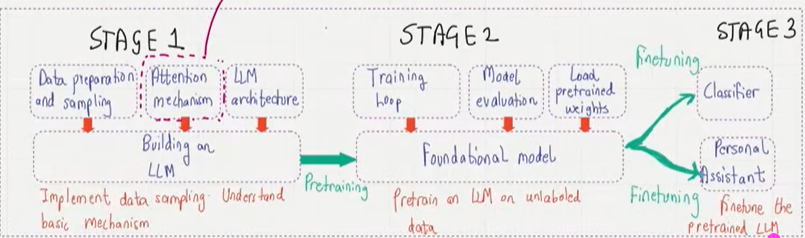

tokneization and embedding

In [ ]:
#getting the book from huggin face
import os
#taking the pdf from the local or huggingface
from datasets import load_dataset

ds = load_dataset("DarwinAnim8or/the-verdict")

##encode method (text to token)

In [ ]:
text_book_list = ds['train']['text'][0:] # text data as a list
text_book_full = " ".join(text_book_list) # join all text into a single string

display(text_book_full[:500]) # Display the first 500 characters of the full text

In [ ]:
#tokenize all the character in the book and then give the token id to them
#actual llm have huge amount of the data
#so to make the otkne we have different librabry in earli we have NLTK now we are usingthe re (regular expression operation)

import re

text="hello my name is meet joshi. I am AI engineer."
result=re.split(r'(\s)',text) # spliting using the white space
print(result)

result=re.split(r'([,.:;?!_"()\\]|--|\s)',text) # spliting using the white space or , .
print(result)

#remove white space character so we loopoing over each result

result=[token for token in result if token!=' ']
print("removed whilte space",result)

#sould we remove the white space ?
"""
advantage is it reduces the memory requirements, while keeping them useful if we train models which is sensitive on the exact structure of the text
ex: if we are training them on python code then white space is imp as python sensitive to indentation and spacing

"""
#aply this to text of the book
token=re.split(r'([,.:;?!_"()\\]|--|\s)',text_book_full)
token_without_space=[token for token in token if token!=' ' and token!=''] # Removed empty strings that can result from split at boundaries
print(token_without_space[:5])

In [ ]:
# 2nd step token to token id for that we are using the vocabulary which is alphabaetacally ordered and token id is given to them also each token gets id {token:id}
# vocab is have unique token and unique id

#so now we need list of unique token in the list which we have created
uniq=list(sorted(set(token_without_space)))
print(len(uniq), uniq[:25])

#assigning id to the token

vocab={}
for i,token in enumerate(uniq):
  vocab[token]=i
# print(vocab.items())





## decode method  (token to text)

 so now we map the token to token id for the input to llm but after the llm process it out put as token then we need mapping to convert the token id ot word
# reverse mapping of the vocabulary

In [ ]:
import re

#making the class
class SimpleTokenizerV1:

  def __init__(self,vocab):
    """
self.str_to_int[token]: For each token from the iteration, this accesses the self.str_to_int dictionary.
This dictionary was initialized in the __init__ method with the provided vocab.
It acts as a lookup table where keys are the string tokens (e.g., 'hello', 'my', 'name') and values are their assigned integer IDs (e.g., 0, 1, 2).
[...]: The result of self.str_to_int[token] (which is the integer ID for that token) is collected for each token, forming a new list of integers. This new list is then assigned to the variable ids.
In essence, for every text token, the code looks up its pre-assigned integer ID in the self.str_to_int dictionary and compiles these IDs into a list.

What can I help you build

"""
    self.str_to_int=vocab # we are passing the vocab not text and vocab is prebuilt in above cell
    self.int_to_str={i:s for s,i in vocab.items()} # Fix: Correctly invert keys and values to map id to string

  def encoder(self,text):
    token=re.split(r'([,.:;?!_"()\\]|--|\s)',text)
    token_without_space=[token for token in token if token!=' ' and token!=''] # Removed empty strings that can result from split at boundaries
    ids=[self.str_to_int[token] for token in token_without_space] # converting the token and giving token id
    return ids

  def decoder(self,ids):
    text=" ".join([self.int_to_str[i] for i in ids])  # here we join the token
    #replace space before the specified punctuation
    text=re.sub(r'\s+([,.?!;"()\\])',r'\1',text) # Fix: \l should be \1 to reference the captured group
    return text

lets instanciate a new tokenizer object from the SimpleTokenizerV1 class and tokenize the text

In [ ]:
ds['train']['text'][10][:100] # further split to 100 letter

In [ ]:
tokenizer=SimpleTokenizerV1(vocab) # creating instance and passing vocab as input
text=ds['train']['text'][10][:100]
converted_id= tokenizer.encoder(text) #invoke the  encode method
print(converted_id)

# nove converting that id to text
convert_text= tokenizer.decoder(converted_id)
print(convert_text)

### now what if we dont have the word in vocab as we have only  token

still there is solution for this issue apart llm train on huge data it moght not have that word

###**special context token**
we can modify the tokenizer to use an unknown token if it encounters a word which is not in the vocab,

so we add a token between the un related text which is endoftext


In [ ]:
#adding 2 tokne into the token list
# 1. Get your list of unique tokens from the book
uniq = list(sorted(set(token_without_space)))

# 2. Define your special tokens
special_tokens = ["<|unk|>", "<|endoftext|>"]

# 3. Add special tokens to the unique list
# (Putting them at the beginning or end is fine, as long as they get unique IDs)
uniq.extend(special_tokens)

# 4. Build the vocabulary dictionary {token: id}
vocab = {}
for i, token in enumerate(uniq):
    vocab[token] = i

print(f"New Vocab Size: {len(vocab)}")
print("Special Token IDs:", vocab["<|unk|>"], vocab["<|endoftext|>"])

In [ ]:
#now we are getting error as we dont have that word in vocab, so to resolve this we need to improve our vocab data and by training on large dataset
#still there is solution for this issue apart llm train on huge data it moght not have that word
# special context token

#handling unknown token  <|unk|> for unknown , |<endoftext>|

#adding the token into vocab

class SimpleTokenizerV2:

    def __init__(self,vocab):

        """
          self.str_to_int[token]: For each token from the iteration,
           this accesses the self.str_to_int dictionary.
           """
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    def encoder(self,text):
        # Fix: Corrected regex to handle `--` as a literal sequence and include `[` and `]`
        token=re.split(r'(<\|endoftext\|>|<\|unk\|>)|([,.:;?!_"()\[\]]|--|\s)',text)
        token_without_space=[token for token in token if token!=' '] # Removed empty strings that can result from split at boundaries

        ids=[self.str_to_int.get(token,self.str_to_int["<|unk|>"]) for token in token_without_space] # converting the token and giving token id
        """
        The .get() method is a useful feature of Python dictionaries. Let me explain how it works in the context of self.str_to_int.get(token, self.str_to_int["<|unk|>"]):

self.str_to_int: This is your vocabulary dictionary, which maps string tokens (like words or punctuation) to their corresponding integer IDs.
.get(key, default_value): This is the dictionary method being called. It tries to retrieve the value associated with the key you provide.
If key (token in this case) exists in the dictionary, .get() returns its associated value (the token's ID).
If key (token) does not exist in the dictionary, .get() returns the default_value you provide instead of raising a KeyError.
token: This is the key you are searching for in the self.str_to_int dictionary. It represents a word or punctuation mark from your input text.
self.str_to_int["<|unk|>"]: This is the default_value. If the token is not found in the vocabulary, this expression provides the integer ID assigned to the special "unknown token" (<|unk|>).
In summary, this line of code attempts to get the ID for a given token. If the token is in the vocabulary, it returns its actual ID. If the token is not in the vocabulary,
it returns the ID for the <|unk|> (unknown) token, effectively handling words that the tokenizer hasn't seen before without crashing.
        """
        return ids

    def decoder(self,ids):
        text=" ".join([self.int_to_str[i] for i in ids])  # here we join the token
        text=re.sub(r'\s+([,.?!;"()\[\]])',r'\1',text) # Fix: Corrected regex for decoder to include `[` and `]`
        return text

In [ ]:
tokenizer=SimpleTokenizerV2(vocab) # creating instance and passing vocab as input
text1="hello i am ai engineer."
text2="i like the story of this book"

text=" <|endoftext|> ".join([text1,text2])
print(text)

converted_id= tokenizer.encoder(text) #invoke the  encode method
#now we are getting error as we dont have that word in vocab, so to resolve this we need to improve our vocab data and by training on large dataset
#still there is solution for this issue apart llm train on huge data it moght not have that word
# special context token
print(len(converted_id))

# nove converting that id to text
convert_text= tokenizer.decoder(converted_id)
print(len(convert_text))

# BPE - byte pair encoding


BPE is relatively comlicated so we will use an existing python open source library tiktoken used by openAI

reduces the vocabulary length and also handles the OOV word using BPE

In [ ]:
!pip install tiktoken

In [ ]:
import importlib, tiktoken

print('version',importlib.metadata.version('tiktoken')) #version 0.13.0

In [ ]:
tokenizer=tiktoken.get_encoding("gpt2") # this is npe tokeniser

this tokenizer is same as the SimpleTokenizerV2 version 2 class it have encoder and decoder for the token for word to int and into to word

In [ ]:
text=['my name is meet joshi <|endoftext|> i like badminton and ramnegi']

integer=tokenizer.encode(text[0], allowed_special={"<|endoftext|>"})
print(integer)

In [ ]:
#convert the token to text
strings=tokenizer.decode(integer)
print(strings) # exactly same output as input

In [ ]:
i=tokenizer.encode("kdjkfha skdn")
i # broken down this word based on subword and assign unique id and get the encoding

# creating input-target data pairs unig DataLoader

###auto regresvie nature where output become input in next iteration so this is unsupervised learning where we just hide the next token from the previous tokens

so here we implement a dataloader that fetches the input-target pairs using a sliding window approach.

so for this first tokenize the whole verdict story book using the BPE which we had done just above

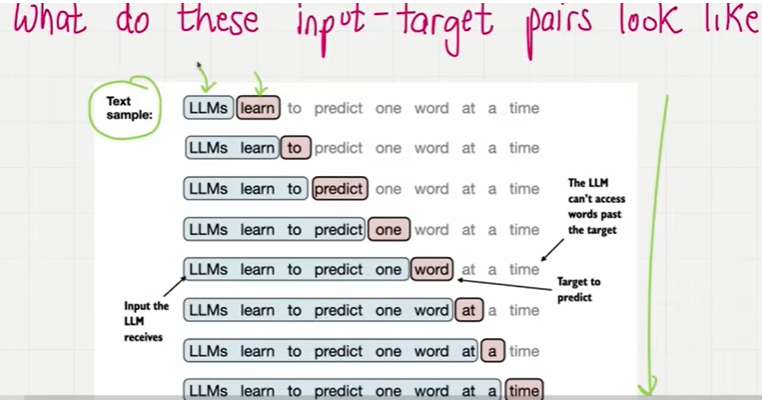

In [ ]:
from datasets import load_dataset

ds = load_dataset("DarwinAnim8or/the-verdict")

text_book_list = ds['train']['text'][0:] # text data as a list
text_book_full = " ".join(text_book_list) # join all text into a single string


In [ ]:
encode_book=tokenizer.encode(text_book_full)
print("number of token after BPE application",len(encode_book))

we remove first 50 token from the encoder list

so to make the context-target based on the context length which we want to provide to llm for predicting the next word


input : [1,2,3,4]
output : [2,3,4,5]

if input is 1,2 then output is 3

if input is 1,2,3 output is 4 likewise

how to decide context size ?

In [ ]:
enc_sample=encode_book[50:] # remove first 50 token
context_size=4 # length of input
x=enc_sample[:context_size] # x is first 4 token input
y=enc_sample[1:context_size+1] # y is the next 4 token
print('x:',x)
print('y:     ',y,'\n target is shift by one position') #for input of  1st token output is 1st token of y

In [ ]:
print('input target data pairs so its not 1 pair its 4 pait for 4 contextual length ')
for i in range(1,context_size+1):
  context=enc_sample[:i]
  target=enc_sample[i]
  print('context',context,'--->>',target,'target')
  print("context",tokenizer.decode(context),'--->>',tokenizer.decode([target]),"<--target")

so this task need to do effeciently in batch mode and for that we are using the **DataLoader** which makes the input and target as **pytorch** **tensor**, which can be thought as multidimentional array, **so we are converting the token id into tensor**

###implement dataloader

we will implement a data loader that fetchs input-output target pairs using sliding window apparoach


as you can see below image where for every input tensor there is 4 sub input-output operation as sliding window shift by 1 we have multiple tensor of input and corrosponding output


so for every input output pair there are 4 prediction task is there where context length increase from i= 1 to 4 word and predicting the i+1^{th} word


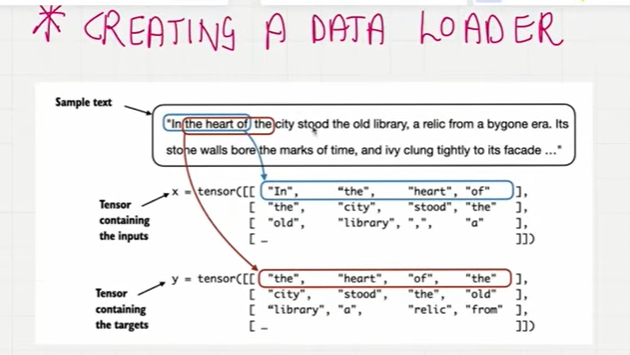

Effecient dataloader implementation

step1: tokenize entire text

step2: use sliding window into overlapping sequence

step3: return total number of row in dataset

step4: return single row from dataset

In [ ]:
from torch.utils.data import Dataset, DataLoader
#### dataset can not be bunch of token data need to be input output pair

class GPTdatasetV1(Dataset):
  """the class thakes the 4 argument at initialisation text, tokenizer(bpe), max_length_context, stride==jump after making one sequence"""
  def __init__(self,txt,tokenizer,max_length_context,stride):
    #storing the input and output sequence in tensor form
    self.input_id=[]
    self.target_id=[]

    #tokenize entire text
    token_ids=tokenizer.encode(txt,allowed_special={"<|endoftext|>"})

    #use sliding window to chunk the book into overlapping sequence of max_length_context
    for i in range(0,len(token_ids)-max_length_context,stride):
      input_ids=torch.tensor(token_ids[i:i+max_length_context])
      target_ids=torch.tensor(token_ids[i+1:i+1+max_length_context])
      self.input_id.append(input_ids)
      self.target_id.append(target_ids)

  def __len__(self):
    return len(self.input_id)

  def __getitem__(self,idx):
    """it returns context and target tesor for that id"""
    return self.input_id[idx],self.target_id[idx]

now we use GPTdatasetV1 to load the inputs in **batches via Pytorch DataLoader**

step1: initialize tokenizer

ste2: create dataset

step3:  drop_last= True **drop the last batch if its shorter than the specified batch size to prevent loss spike during training**

step4: the number of **CPU processes to use for preprocessing**

In [ ]:
def create_dataloader_v1(txt,batch_size=4,max_length=256,stride=128,shuffle=True,drop_last=True,num_workers=0):
  #### batch_size means number of data it process in one iteration and num_worker decides how many cpus /cpre you want to run parralelly
  #max_len for gpt its 256 awhich shows the 256 previous word and predict the next
  #initiaize tokenizer
  tokenizer=tiktoken.get_encoding("gpt2")
  #create dataset using the above function which make context-target tensor
  dataset= GPTdatasetV1(txt,tokenizer,max_length,stride)

  #create dataloader
  dataloader=DataLoader(dataset,
                        batch_size=batch_size,
                        shuffle=shuffle,
                        drop_last=drop_last,
                        num_workers=num_workers
                  )
  """so this DataLoader get the data from the getitem function of the GPTdatasetV1"""
  return dataloader

In [ ]:
import torch
dataloader=create_dataloader_v1(text_book_full, batch_size=1,stride=1,max_length=4,shuffle=False)

data_iter=iter(dataloader)
first_batch=next(data_iter)
print('first_batch',first_batch)#input and output token tensors

second_batch=next(data_iter)
print('second_batch',second_batch)#input and output token tensors

NOTE: input size of 4 is relatively small in real case to train LLM we need around input tensor size = 256 length



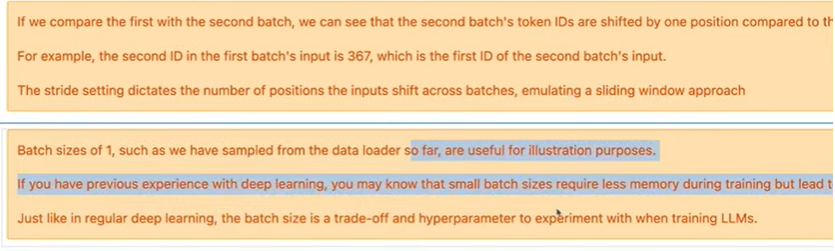

effect of batch size and stride

larger stride removes the overlaping problem between batches , as overlapping can do overfitting.

In [ ]:
import torch
dataloader=create_dataloader_v1(text_book_full, batch_size=8,stride=4,max_length=4,shuffle=False)

data_iter=iter(dataloader)
first_batch=next(data_iter)
print('first_batch',first_batch)#input and output token tensors


### vector embedding

In [ ]:
!pip install gensim

In [ ]:
# import gensim.downloader as api
# model=api.load("word2vec-google-news-300")# this return the embedding for the million of word where encoding dim=300

# word_vectors=model
# #let look how the vector embedding of word look like
# # print('computer 300 dim vecotr',word_vectors['computer'])

# ## looking the famous exaple king+women-men= ?

# print('king+women-men=',word_vectors.most_similar(positive=['king','women'],negative=['men']))

# print(word_vectors.similarity('king','queen'))
# print(word_vectors.similarity('deep','learning'))
# print(word_vectors.similarity('uncle','aunty'))

# print(word_vectors.most_similar('uncle'))
# input_token_id=torch.tensor([2,3,5,1]) # we are giving everythin in tensor due to backpropogation we do

# # so for simplicuty we use vocab size of 6 and create embedding of size 3

# # using the vocab size and output dim initiate the embedding layer with random number with seed value so we can reproduce it


# vocab_size=6
# output_dim=3
"""so for simplicuty we use vocab size of 6 and create embedding of size 3

using the vocab size and output dim initiate the embedding layer with random number with seed value so we can reproduce it """
# torch.manual_seed(123)
# #initialize the mebedding matrix with random initialization for every word 3 dim embedding randomly given
# embedding_layer=torch.nn.Embedding(vocab_size,output_dim)
# embedding_layer

# so these are the weights we optimize during the LLM training to get the proper word to vec representation of word everything is in tensor
# print(embedding_layer.weight)

# #get the tensor for every word index start from 0
# embedding_layer(torch.tensor([3])) # soo for the token id 3 its embedding is
"""
so these are the weights we optimize during the LLM training to get the proper word to vec representation of word everything is in tensor
"""
# #so now we need multiple embedding for different token id
# embedding_layer(torch.tensor([1,2,3]))

checking the similarity between the words

### coding token embedding layer

converting the token id to embedding vector

##positional encoding

torch.nn.Embedding(vocab_size, output_dim), PyTorch creates a massive look-up table (in your case, a matrix of size $50257 \times 256$) and fills it with random floating-point numbers (typically **drawn from a standard normal distribution**).

Here is what you need to keep in mind about this layer:**It acts like a lookup dictionary**: **When you pass a token ID (like 40), it doesn't do any math; it just goes to row 40 of this random matrix and pulls out those 256 numbers.**

These are the weights your LLM will learn: Right now, the embeddings are completely random, meaning the vector for "apple" and "orange" won't look any more similar than the vector for "apple" and "refrigerator". As you train your model on the book data, backpropagation will slowly adjust these numbers so that words used in similar contexts end up with similar embedding vectors

In [ ]:
vocab_size=50257
output_dim=256
#randomlygnerate the embedding for every token
token_embedding_layer=torch.nn.Embedding(vocab_size,output_dim)

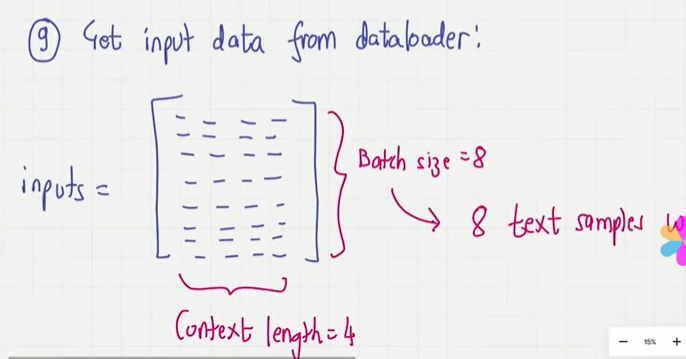

In [ ]:
#now we use the DataLoaderV1 which we have made to load the data in particular batch and embedding size for training input
#so each row has 4 token id which predicts the next token id as its target value

#now we have to convet each token id of 4 to 4 embedding layer correspons to token id

#lets initialize the dataloder
max_length=4
dataloader=create_dataloader_v1(text_book_full,batch_size=8 ,max_length=max_length, stride=max_length,shuffle=False)

data_iter=iter(dataloader)
input,target=next(data_iter)

In [ ]:
print("batch of input token id",input)
print("input shape",input.shape)

now we conver thes each token id into 256 embedding layer torch.nn.embedding which randoly generate embedding of 256 dim (3D vector) and

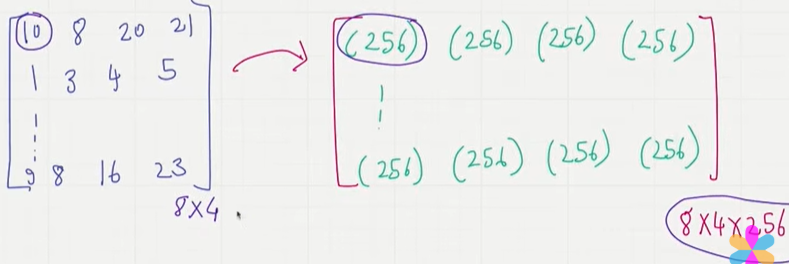

lets conver the 2d matrix to 3d matrix of dim 8 * 4 * 256

In [ ]:
token_embedding=token_embedding_layer(input) # passing whole matrix in one time

token_embedding.shape


now for the positional embedding we need to create another embedding layer with the same dimenssion

for one time 4 token given to predict next word processes so we need 4 positional emebdding at time

thats why its size is 4*256, where 4=number of input toekn id at time

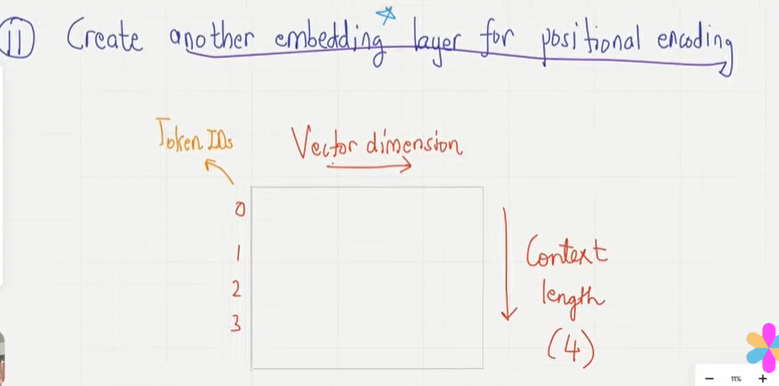

In [ ]:
context_length=max_length
pos_embedding_layer=torch.nn.Embedding(context_length,output_dim)

 ### as you can see in the input 8 * 4 *256 where at one time 8 exmaple is sent to llm in iterative manner for predicting next orkd, after this

 we are trying to add the positional encoding for every row as this are the 4 token sent to llm for predict the next word so for all 8 example **in input the total position is 4 so the position is same in every time so the positional encodding which we have used in 1st example we can use it 7th or any exaple in input matrix**

 so [4 * 256] table we need to create only

In [ ]:
#to lookup torch.arange(size) used here
print("passing the value to generate positional embedding which is same as input token length",torch.arange(max_length))
pos_embedding=pos_embedding_layer(torch.arange(max_length))
print(pos_embedding)
print(pos_embedding.shape)

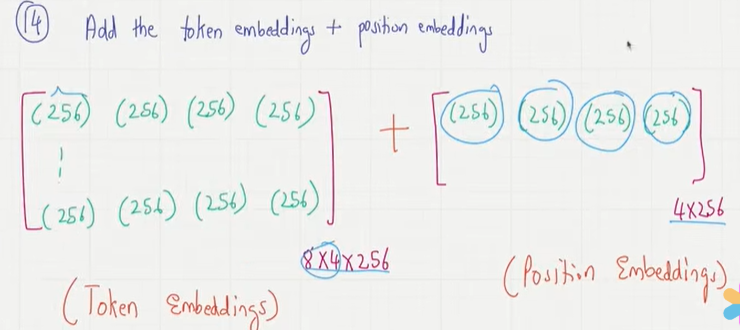

adding positional embedding into the input embedding

where input is in 3d (8 * 4 *256) and pos dim in 2d (4 * 256 )

so iteratively take the batch or do **broadcasting: which means repeate the embedding value 8 time so now the matrix size become same 8 * 4 * 256 so same 4 value of positional embedding is added into the input embedding**

so these both input embedding matrix and positional embedding marix weights are learn during the training of the llm

To expand your 2D positional embedding matrix pos_embedding (which has a shape of [4, 256]) into a 3D matrix (with a shape of [8, 4, 256]) to match your input token embeddings, you can use .

**unsqueeze() combined with .expand().**

In [ ]:
#converting the pos embedding from 2D to 3D of same size as input
# input embedding = input embedding + positional embedding

# 1. Add a new dimension at the very front (dim=0) -> shape becomes [1, 4, 256]
#unsqueeze(0): Creates a temporary "batch" dimension of size 1 so PyTorch knows where you want to copy the data.
pos_embedding_3d = pos_embedding.unsqueeze(0)
print(pos_embedding_3d.shape)

# 2. Expand/broadcast that first dimension to match your batch size of 8 -> shape becomes [8, 4, 256]
batch_size = input.shape[0]  # which is 8

"""
expand(batch_size, -1, -1): Efficiently replicates the matrix 8 times along that new dimension without actually allocating new memory for it.
Passing -1 tells PyTorch to leave the other dimensions (4 and 256) exactly as they are.
"""
pos_embedding_3d = pos_embedding_3d.expand(batch_size, -1, -1)

# 3. Add them together!
input_embedding = token_embedding + pos_embedding_3d

print("3D Positional Embedding Shape:", pos_embedding_3d.shape)
print("Final Combined Embedding Shape:", input_embedding.shape)

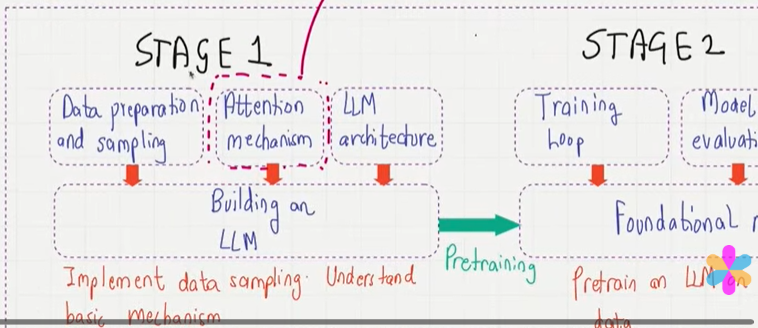

# attention mechanism (M-IMP)

In [ ]:
import torch
import torch.nn as nn

# ==========================================
# STEP 1: Define Input Embeddings (3D space)
# ==========================================
inputs = torch.tensor([
    [0.43, 0.15, 0.89],  # Your    (x^1)
    [0.55, 0.87, 0.66],  # journey (x^2)
    [0.57, 0.85, 0.64],  # starts  (x^3)
    [0.22, 0.58, 0.33],  # with    (x^4)
    [0.77, 0.25, 0.10],  # one     (x^5)
    [0.05, 0.80, 0.55]   # step    (x^6)
])

# ==========================================================
# DEMONSTRATION: Computing Context Vector for a Single Word
# Query = "journey" (Index 1)
# ==========================================================
query = inputs[1]

# 1. Compute attention scores via dot-product
attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)
print("Attention Scores (for Journey):", attn_scores_2)

# 2. Normalization via Naive Softmax implementation
def naive_softmax(x):
    return torch.exp(x) / torch.sum(torch.exp(x), dim=0)

attn_weights_2_naive = naive_softmax(attn_scores_2)
print("Attention Weights (Naive Softmax):", attn_weights_2_naive)

# Normalization using PyTorch's stable Softmax
attn_weights_2_stable = torch.softmax(attn_scores_2, dim=0)
print("Attention Weights (PyTorch Softmax):", attn_weights_2_stable)

# 3. Compute the final context vector for "journey"
context_vector_2 = torch.zeros(query.shape)
for i, x_i in enumerate(inputs):
    context_vector_2 += attn_weights_2_stable[i] * x_i
print("Context Vector (for Journey):", context_vector_2)


# ==========================================================
# FULL SENTENCE COMPUTATION: Efficient Matrix Implementation
# ==========================================================

# 1. Compute attention scores for all words using matrix multiplication
attn_scores = torch.matmul(inputs, inputs.T)
print("\nFull Attention Scores Matrix (6x6):\n", attn_scores)

# 2. Apply Softmax row-wise to get normalized attention weights
attn_weights = torch.softmax(attn_scores, dim=-1)
print("\nFull Attention Weights Matrix (6x6):\n", attn_weights)

# 3. Compute final context vectors for all tokens
all_context_vectors = torch.matmul(attn_weights, inputs)
print("\nAll Context Vectors Matrix (6x3):\n", all_context_vectors)

In [ ]:
import torch
import torch.nn as nn

# ==========================================
# STEP 1: Define Input Embeddings (3D space)
# ==========================================
inputs = torch.tensor([
    [0.43, 0.15, 0.89],  # Your    (x^1)
    [0.55, 0.87, 0.66],  # journey (x^2)
    [0.57, 0.85, 0.64],  # starts  (x^3)
    [0.22, 0.58, 0.33],  # with    (x^4)
    [0.77, 0.25, 0.10],  # one     (x^5)
    [0.05, 0.80, 0.55]   # step    (x^6)
])

# ==========================================================
# DEMONSTRATION: Computing Context Vector for a Single Word
# Query = "journey" (Index 1)
# ==========================================================
query = inputs[1]

# 1. Compute attention scores via dot-product
attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)
print("Attention Scores (for Journey):", attn_scores_2)

# 2. Normalization via Naive Softmax implementation
def naive_softmax(x):
    return torch.exp(x) / torch.sum(torch.exp(x), dim=0)

attn_weights_2_naive = naive_softmax(attn_scores_2)
print("Attention Weights (Naive Softmax):", attn_weights_2_naive)

# Normalization using PyTorch's stable Softmax
attn_weights_2_stable = torch.softmax(attn_scores_2, dim=0)
print("Attention Weights (PyTorch Softmax):", attn_weights_2_stable)

# 3. Compute the final context vector for "journey"
context_vector_2 = torch.zeros(query.shape)
for i, x_i in enumerate(inputs):
    context_vector_2 += attn_weights_2_stable[i] * x_i
print("Context Vector (for Journey):", context_vector_2)


# ==========================================================
# FULL SENTENCE COMPUTATION: Efficient Matrix Implementation
# ==========================================================

# 1. Compute attention scores for all words using matrix multiplication
attn_scores = torch.matmul(inputs, inputs.T)
print("\nFull Attention Scores Matrix (6x6):\n", attn_scores)

# 2. Apply Softmax row-wise to get normalized attention weights
attn_weights = torch.softmax(attn_scores, dim=-1)
print("\nFull Attention Weights Matrix (6x6):\n", attn_weights)

# 3. Compute final context vectors for all tokens
all_context_vectors = torch.matmul(attn_weights, inputs)
print("\nAll Context Vectors Matrix (6x3):\n", all_context_vectors)

In [ ]:
import torch

# =====================================================================
# STEP 1: Define Input Embeddings (3-Dimensional Space)
# We choose a small embedding dimension for illustration purposes
# to ensure it fits on the page without line breaks.
# Each row represents a token, and each column represents a dimension.
# =====================================================================

inputs = torch.tensor([
    [0.43, 0.15, 0.89],  # Your    (x^1)
    [0.55, 0.87, 0.66],  # journey (x^2)
    [0.57, 0.85, 0.64],  # starts  (x^3)
    [0.22, 0.58, 0.33],  # with    (x^4)
    [0.77, 0.25, 0.10],  # one     (x^5)
    [0.05, 0.80, 0.55]   # step    (x^6)
])

# =====================================================================
# STEP 2: Compute Intermediate Attention Scores (Dot Products)
# The dot product quantifies how much two vectors are aligned.
# Higher dot product = higher similarity and attention score.
#
# Instead of slow Python loops, we use an efficient matrix product:
#   Inputs (6x3) multiplied by Inputs Transposed (3x6) -> Scores (6x6)
# Each row represents a query token's relation to all input tokens.
# =====================================================================

attn_scores = torch.matmul(inputs, inputs.T)
print("Full Attention Scores Matrix (6x6):\n", attn_scores)

# =====================================================================
# STEP 3: Normalization via Softmax to Obtain Attention Weights
# The main goal of normalization is to obtain attention weights that
# sum up to 1. This is useful for interpretability (percentages).
#
# In practice, it's advisable to use the PyTorch implementation of
# softmax to avoid numerical instability (overflow/underflow issues).
#
# dim=-1 instructs softmax to apply normalization along the last
# dimension (across columns), ensuring values in each row sum up to 1.
# =====================================================================

attn_weights = torch.softmax(attn_scores, dim=-1)
print("\nFull Attention Weights Matrix (6x6):\n", attn_weights)

# =====================================================================
# STEP 4: Compute the Final Enriched Context Vectors
# To get the final context vectors, we multiply the attention weights matrix
# with the input matrix.
#
# This operation scales every input vector by its respective attention
# weight and sums them up. The result is an enriched context vector
# matrix containing contextual information for all tokens.
# =====================================================================

all_context_vectors = torch.matmul(attn_weights, inputs)
print("\nAll Context Vectors Matrix (6x3):\n", all_context_vectors)

### self attention with learnable parameter key,query, value

Core Structural Explanations Covered Why add projection matrices ($W_Q, W_K, W_V$)?

In basic attention, similarity is derived directly from static input embeddings. By adding trainable linear layer configurations ($W_Q, W_K, W_V$), the model can project the exact same semantic input into three completely unique operational roles:

Query ($Q$): What the current token is actively searching or looking for in the sentence.

Key ($K$): How the current token describes itself to match other tokens' queries.

Value ($V$): The actual semantic data content that gets passed along once a strong matching relationship between a Query and Key is established.

The Scaled Dot-Product Metric:The attention scores are divided by $\sqrt{d_{out}}$ (the square root of the hidden projection dimensions). When dimensions get large, dot products grow immensely in magnitude. Passing large values into a Softmax causes its gradients to become virtually zero **(vanishing gradient problem)**. Dividing by the scaling factor ensures stable gradient flows during network training blocks.

In [ ]:
import torch
import torch.nn as nn

# =====================================================================
# STEP 1: Define Input Embeddings and Dimensions
# =====================================================================
# In a real LLM, we don't pass raw words; we pass word embeddings.
# Let's assume we have an input sequence of 6 tokens, where each token
# is represented by a 3-dimensional vector (d_in = 3).
# ---------------------------------------------------------------------
inputs = torch.tensor([
    [0.43, 0.15, 0.89],  # Your    (x^1)
    [0.55, 0.87, 0.66],  # journey (x^2)
    [0.57, 0.85, 0.64],  # starts  (x^3)
    [0.22, 0.58, 0.33],  # with    (x^4)
    [0.77, 0.25, 0.10],  # one     (x^5)
    [0.05, 0.80, 0.55]   # step    (x^6)
])

x_2 = inputs[1] # Let's keep a reference to the second token ("journey") for step-by-step demo

d_in = inputs.shape[1]  # Input embedding dimension (3) for dot product need to be same as embedding length
d_out = 2                # Output dimension for Queries, Keys, and Values (2)

print(f"Input Shape: {inputs.shape} (Num tokens: {inputs.shape[0]}, Embedding size: {d_in})")
print(f"Target Output Dimension (d_out): {d_out}\n")

# =====================================================================
# STEP 2: Initialize Trainable Weight Matrices (W_q, W_k, W_v)
# =====================================================================
# Unlike basic dot-product attention, advanced self-attention uses
# projection matrices that are trained via backpropagation.
# They allow the model to map input embeddings into specialized spaces.
#
# Note: Setting requires_grad=False here just for cleanly printing static
# results, but these are updated during actual model training. we will set it tu True
# ---------------------------------------------------------------------
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

print("Weight Matrix W_query:\n", W_query)
print("Weight Matrix W_key:\n", W_key)
print("Weight Matrix W_value:\n", W_value)
print("-" * 50)


# =====================================================================
# STEP 3: Conceptual Step-by-Step for a Single Token (e.g., x_2 "journey")
# =====================================================================
# Let's derive the Query, Key, and Value vectors specifically for x_2.
# ---------------------------------------------------------------------

# Compute Query vector for x_2, and Key/Value vectors for all elements
query_2 = torch.matmul(x_2, W_query)
key_2= x_2 @ W_key
value_2 = x_2 @ W_value
print("query_2,key_2,value_2",query_2,key_2,value_2)

keys = torch.matmul(inputs, W_key)
values = torch.matmul(inputs, W_value)
queries=torch.matmul(inputs,W_query)
print(f"\nkey, value, query amtrix, all size, {queries.shape} {keys.shape} {values.shape}")


Input Shape: torch.Size([6, 3]) (Num tokens: 6, Embedding size: 3)
Target Output Dimension (d_out): 2

Weight Matrix W_query:
 Parameter containing:
tensor([[0.3821, 0.6605],
        [0.8536, 0.5932],
        [0.6367, 0.9826]])
Weight Matrix W_key:
 Parameter containing:
tensor([[0.2745, 0.6584],
        [0.2775, 0.8573],
        [0.8993, 0.0390]])
Weight Matrix W_value:
 Parameter containing:
tensor([[0.9268, 0.7388],
        [0.7179, 0.7058],
        [0.9156, 0.4340]])
--------------------------------------------------
query_2,key_2,value_2 tensor([1.3730, 1.5279]) tensor([0.9860, 1.1337]) tensor([1.7386, 1.3068])

key, value, query amtrix, all size, torch.Size([6, 2]) torch.Size([6, 2]) torch.Size([6, 2])


In [ ]:

# Compute unnormalized attention scores (\omega) for x_2 against all keys
# \omega_2,i = query_2 \cdot key_i
attn_scores_2 = torch.empty(inputs.shape[0])

for i, key_i in enumerate(keys):
    attn_scores_2[i] = torch.dot(query_2, key_i)
print("[Single Token Demo] Attention Scores (\u03c9_2):", attn_scores_2)

# Compute Scaled Attention Weights using Softmax with Scaled Dot-Product scaling
# Scaling factor = 1 / \sqrt{d_out} prevents gradients from exploding/vanishing
d_k = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / (d_k ** 0.5), dim=-1)
print("[Single Token Demo] Scaled Attention Weights (\u03b1_2):", attn_weights_2)

# Compute Content Enriched Context Vector (z_2) for the second token
context_vector_2 = torch.zeros(d_out)
for i, value_i in enumerate(values):
    context_vector_2 += attn_weights_2[i] * value_i
print("[Single Token Demo] Resulting Context Vector (z_2):", context_vector_2)
print("-" * 50,"\n")

print("\nattention score matrix before training q.k^T \n",queries @ keys.T)
print("normalisig attention score to become attention weights\n",torch.softmax((queries @ keys.T)/keys.shape[-1],dim=-1))



[Single Token Demo] Attention Scores (ω_2): tensor([2.0002, 3.0859, 3.0539, 1.7121, 1.6169, 2.1338])
[Single Token Demo] Scaled Attention Weights (α_2): tensor([0.1260, 0.2714, 0.2654, 0.1027, 0.0961, 0.1384])
[Single Token Demo] Resulting Context Vector (z_2): tensor([1.4410, 1.0669])
-------------------------------------------------- 


attention score matrix before training q.k^T 
 tensor([[1.3816, 2.2613, 2.2399, 1.2622, 1.2231, 1.5509],
        [2.0002, 3.0859, 3.0539, 1.7121, 1.6169, 2.1338],
        [1.9708, 3.0433, 3.0118, 1.6886, 1.5954, 2.1040],
        [1.1209, 1.7006, 1.6825, 0.9418, 0.8826, 1.1787],
        [0.8856, 1.4194, 1.4055, 0.7906, 0.7594, 0.9762],
        [1.4780, 2.2256, 2.2016, 1.2316, 1.1500, 1.5442]])
normalisig attention score to become attention weights
 tensor([[0.1420, 0.2204, 0.2181, 0.1338, 0.1312, 0.1545],
        [0.1394, 0.2398, 0.2360, 0.1207, 0.1151, 0.1490],
        [0.1397, 0.2388, 0.2351, 0.1213, 0.1158, 0.1493],
        [0.1540, 0.2058, 0.2040, 

Why Scaling is Crucial for Self-AttentionThe Problem: The variance of the dot product of two $d$-dimensional random vectors with mean 0 and variance 1 is exactly $d$.

If $d = 1000$, your attention scores before the softmax will have massive differences.

The Softmax Trap: When you pass exceptionally large numbers into the softmax function, the largest value dominates completely, driving its probability close to $1.0$ and pushing all other probabilities to $0.0$.

Vanishing Gradients: In this state, the gradients of the softmax function become practically zero.

This effectively kills backpropagation, making it impossible for the model to learn. Dividing by $\sqrt{d_{in}}$ pulls the variance back down to $1$, ensuring smooth training.

In [ ]:
import numpy as np

# =====================================================================
# Function to compute variance before and after scaling
# =====================================================================
# When input dimensions (d_in) become large, the dot products grow
# significantly in magnitude. This function simulates this behavior
# to demonstrate how scaling controls the variance.
# ---------------------------------------------------------------------
def compute_variance(d_in, num_trials=1000):
    dot_products = []
    scaled_dot_products = []

    # Generate multiple random vectors and compute dot products
    for _ in range(num_trials):
        # Generate two random vectors with mean 0 and variance 1
        q = np.random.randn(d_in)
        k = np.random.randn(d_in)
        # print(q,k)

        # Compute dot product
        dot_product = np.dot(q, k)
        dot_products.append(dot_product)

        # Scale the dot product by sqrt(dim)
        scaled_dot_product = dot_product / np.sqrt(d_in)
        scaled_dot_products.append(scaled_dot_product)

    # Calculate variance of the dot products
    var_unscaled = np.var(dot_products)
    var_scaled = np.var(scaled_dot_products)

    return var_unscaled, var_scaled

# =====================================================================
# Demonstration & Testing
# =====================================================================
# Notice how as d_in increases, the unscaled variance grows linearily
# with the dimension, while the scaled variance stays perfectly at 1.
# ---------------------------------------------------------------------
print(f"{'Dimension (d_in)':<20}{'Unscaled Variance':<25}{'Scaled Variance':<20}")
print("-" * 65)

for dim in [10, 100, 1000]:
    v_unscaled, v_scaled = compute_variance(dim)
    print(f"{dim:<20}{v_unscaled:<25.4f}{v_scaled:<20.4f}")

Dimension (d_in)    Unscaled Variance        Scaled Variance     
-----------------------------------------------------------------
10                  10.0087                  1.0009              
100                 100.3756                 1.0038              
1000                940.3362                 0.9403              


In [ ]:

# =====================================================================
# STEP 4: Fully Vectorized Matrix Computations (The Matrix Trick)
# =====================================================================
# In production, processing token by token using loops is highly inefficient.
# We calculate Queries, Keys, and Values for all words simultaneously using
# optimized matrix operations.
# ---------------------------------------------------------------------

# 1. Project all inputs into total Q, K, V matrices
# Inputs (6x3) x Weight (3x2) -> Result (6x2)
Q = torch.matmul(inputs, W_query)
K = torch.matmul(inputs, W_key)
V = torch.matmul(inputs, W_value)

# 2. Compute all attention scores at once
# We multiply Queries (6x2) by Keys Transposed (2x6) to get a 6x6 score grid
# Formula: \Omega = Q \times K^T
all_attn_scores = torch.matmul(Q, K.T)

# 3. Normalize across rows with Scaled Softmax
# dim=-1 ensures normalization happens along each row independently
all_attn_weights = torch.softmax(all_attn_scores / (d_k**0.5), dim=-1) #dim=-1 because we want to sum over column equal to 1

# 4. Compute all context vectors simultaneously
# Weights (6x6) x Values (6x2) -> Context Vectors (6x2)
# Formula: Z = Attention_Weights \times V
all_context_vectors = torch.matmul(all_attn_weights, V)

print("\n=== Optimized Matrix Results ===")
print("\nAll Attention Weights Matrix (6x6):\n", all_attn_weights)
print("\nAll Context Vectors Matrix (6x2):\n", all_context_vectors)



=== Optimized Matrix Results ===

All Attention Weights Matrix (6x6):
 tensor([[0.1309, 0.2439, 0.2402, 0.1203, 0.1170, 0.1476],
        [0.1260, 0.2714, 0.2654, 0.1027, 0.0961, 0.1384],
        [0.1265, 0.2700, 0.2640, 0.1036, 0.0970, 0.1390],
        [0.1479, 0.2228, 0.2200, 0.1303, 0.1250, 0.1541],
        [0.1467, 0.2139, 0.2118, 0.1371, 0.1341, 0.1564],
        [0.1419, 0.2408, 0.2367, 0.1192, 0.1126, 0.1487]])

All Context Vectors Matrix (6x2):
 tensor([[1.4035, 1.0391],
        [1.4410, 1.0669],
        [1.4391, 1.0655],
        [1.3786, 1.0178],
        [1.3653, 1.0086],
        [1.4025, 1.0361]])


##covering all this thing into one class

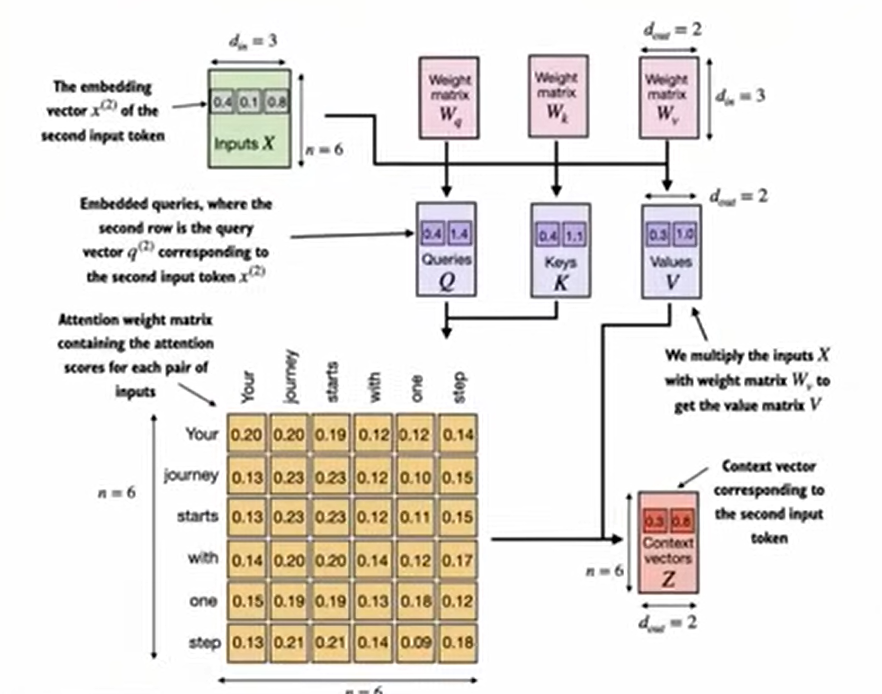

In [ ]:
import torch
import torch.nn as nn

class SelfAttention_v1(nn.Module):
  # nn.Module is the base class for all neural network modules in PyTorch.
  # It provides functionalities like tracking parameters, moving modules to GPU, etc.

  def __init__(self,d_in,d_out):
    super().__init__()
    # super().__init__() calls the constructor of the parent class (nn.Module).
    # This is essential for proper initialization of the PyTorch module.
    self.w_query=nn.Parameter(torch.rand(d_in,d_out))
    self.w_key=nn.Parameter(torch.rand(d_in,d_out))
    self.w_value=nn.Parameter(torch.rand(d_in,d_out))

  def forward(self,x):

    query=torch.matmul(x,self.w_query)
    key=torch.matmul(x,self.w_key)
    value=torch.matmul(x,self.w_value)
    #attention score
    attention_score = (query @ key.T )/(key.shape[-1]**0.5)
    #attention value
    attention_val=torch.softmax(attention_score,dim=-1)

    context_vector=torch.matmul(attention_val,value)
    return context_vector

In [ ]:
torch.manual_seed(123)
sa_v1=SelfAttention_v1(d_in=3,d_out=2)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


imporve self attetion initialisation


In [ ]:
import torch
import torch.nn as nn

class SelfAttention_v2(nn.Module):
  # nn.Module is the base class for all neural network modules in PyTorch.
  # It provides functionalities like tracking parameters, moving modules to GPU, etc.

  def __init__(self,d_in,d_out,bias=False):
    super().__init__()
    # super().__init__() calls the constructor of the parent class (nn.Module).
    # This is essential for proper initialization of the PyTorch module.

    #linear initialization provides better wt and stable learning
    self.w_query=nn.Linear(d_in,d_out,bias)
    self.w_key=nn.Linear(d_in,d_out,bias)
    self.w_value=nn.Linear(d_in,d_out,bias)

  def forward(self,x):
    """layers are callable modules, not simple tensors. I need to call self.w_query(x) instead of using torch.matmul(x, self.w_query)"""
    query=self.w_query(x)
    key=self.w_key(x)
    value=self.w_value(x)
    #attention score
    attention_score = (query @ key.T )/(key.shape[-1]**0.5)
    #attention value
    attention_val=torch.softmax(attention_score,dim=-1)

    context_vector=torch.matmul(attention_val,value)
    return context_vector

In [ ]:
torch.manual_seed(123)
sa_v2=SelfAttention_v2(d_in=3,d_out=2)
print(sa_v2(inputs))

tensor([[-0.5337, -0.1051],
        [-0.5323, -0.1080],
        [-0.5323, -0.1079],
        [-0.5297, -0.1076],
        [-0.5311, -0.1066],
        [-0.5299, -0.1081]], grad_fn=<MmBackward0>)


## causal self-attention implemetation

To ensure the model doesn't look at future words (data leakage), an upper triangular mask is applied to the raw scores. All positions representing future tokens are filled with negative infinity ($-\infty$)

The scores are divided by the square root of the key dimension (for training stability). Then, a softmax function is applied. This turns the $-\infty$ values into exact 0s and normalizes each row so the weights sum up to 1

In [2]:
import torch

# --- STEP 1: Define Raw Attention Scores & Target Dimensions ---
# Let's assume we have an incoming raw attention score matrix (Q @ K.T) for 6 tokens.
# Shape: (Num_Tokens, Num_Tokens) -> (6, 6)
attn_scores = torch.tensor([
    [ 1.2, -0.4,  0.5,  0.1, -0.8,  0.9],
    [-0.2,  2.1, -1.1,  0.3,  0.0, -0.5],
    [ 0.7,  0.1,  1.5, -0.6,  0.8,  0.2],
    [-0.9,  0.4,  0.2,  2.5, -1.3,  0.1],
    [ 0.3, -0.7,  0.9,  0.0,  1.1, -0.2],
    [ 0.1,  0.8, -0.4,  0.6, -0.1,  1.8]
])

# Scale by the square root of Key dimensions (let's assume d_k = 2) and apply standard Softmax
scaled_scores = attn_scores / (2 ** 0.5)
attn_weights = torch.softmax(scaled_scores, dim=-1)
print("Standard Attention Weights (Rows sum up to 1):\n", attn_weights)
print("-" * 50)

# --- STEP 2: Generate a Simple Lower-Triangular Mask (Trill) ---
# We use torch.trill to keep the diagonal and everything below it as 1, and make above it 0.
context_length = attn_weights.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print("Lower-Triangular Mask (ones and zeros):\n", mask_simple)
print("-" * 50)

# --- STEP 3: Multiply Weights by the Mask to Hide Future Words ---
# This forces all elements above the diagonal to become exactly 0.
masked_weights_simple = attn_weights * mask_simple
print("Masked Weights (Future tokens zeroed out):\n", masked_weights_simple)
print("-" * 50)

# --- STEP 4: Manually Renormalize Each Row ---
# Because we zeroed out elements, the rows no longer sum up to 1.
# We calculate the sum of each row and divide every element in that row by its sum.
row_sums = masked_weights_simple.sum(dim=-1, keepdim=True)
masked_simple_normalized = masked_weights_simple / row_sums

print("Final Normalized Basic Causal Weights:\n", masked_simple_normalized)

# Verification check: Check if all rows now accurately sum back to 1.0
print("\nVerification - New Row Sums:\n", masked_simple_normalized.sum(dim=-1))

Standard Attention Weights (Rows sum up to 1):
 tensor([[0.2904, 0.0937, 0.1770, 0.1334, 0.0706, 0.2349],
        [0.1000, 0.5086, 0.0529, 0.1424, 0.1152, 0.0809],
        [0.1789, 0.1171, 0.3150, 0.0714, 0.1920, 0.1256],
        [0.0512, 0.1284, 0.1114, 0.5666, 0.0386, 0.1038],
        [0.1589, 0.0783, 0.2429, 0.1285, 0.2798, 0.1116],
        [0.1116, 0.1830, 0.0784, 0.1589, 0.0969, 0.3712]])
--------------------------------------------------
Lower-Triangular Mask (ones and zeros):
 tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])
--------------------------------------------------
Masked Weights (Future tokens zeroed out):
 tensor([[0.2904, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1000, 0.5086, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1789, 0.1171, 0.3150, 0.0000, 0.0000, 0.0000],
        [0.0512, 0.1284, 0.1114, 0.56

**The Smart Masking Trick:**

Instead of calculating softmax() first and then setting future tokens to zero (which leads to **data leakage** because future elements already altered the weights in the denominator), the code sets future attention positions to -inf prior to softmax(). When softmax() computes $e^{-\infty}$, it turns natively into 0 and perfectly scales the remaining historical weights.

**Why register_buffer? :**

 The matrix mask contains fixed values (1s and 0s) that do not require gradient optimization. Registering it as a buffer binds it to the module state so that when you move your model parameters onto a GPU architecture, the mask updates location smoothly in tandem, preventing device mismatch runtime errors.

In [ ]:
import torch
import torch.nn as nn

class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout_rate=0.0):
        super().__init__()
        self.d_out = d_out

        # Trainable weight matrices to project input embeddings into Keys, Queries, and Values
        self.W_key = nn.Linear(d_in, d_out, bias=False)
        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)

        # Dropout layer to apply over attention weights to prevent overfitting
        self.dropout = nn.Dropout(dropout_rate)

        # Upper triangular mask filled with 1s above the diagonal (used for masking future tokens)
        # We use register_buffer so it's treated as model state but not a trainable parameter.
        # This automatically moves the tensor to the correct device (CPU/GPU) with the model.
        # triu for upper triangular and tril for lower tringular
        #context length is also imprtant parameter rn we have only 6 word so we are takign all at once but for lasrge sentense we ahve to decide context elngth
        self.register_buffer(
            'mask',
            torch.tril(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        # x shape: (Batch_Size, Num_Tokens, Embedding_Dim_In) -> e.g., (2, 6, 3)
        b, num_tokens, d_in = x.shape

        # Step 1: Project inputs to calculate Keys, Queries, and Values
        # Shapes: (Batch_Size, Num_Tokens, Embedding_Dim_Out)
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Step 2: Compute Attention Scores by multiplying Queries and Keys (transposed)
        # We transpose dimensions 1 and 2 of the keys to execute matrix multiplication batch-by-batch.
        # keys.transpose(1, 2) shape: (Batch_Size, Embedding_Dim_Out, Num_Tokens)
        # attn_scores shape: (Batch_Size, Num_Tokens, Num_Tokens)
        attn_scores = queries @ keys.transpose(1, 2)

        # Step 3: Avoid Data Leakage using an Upper Triangular Infinity Mask
        # We slice the pre-registered mask to match the current sequence token count.
        # mask_fill replaces positions where the mask is 1 (future words) with negative infinity (-inf).
        # This ensures future words don't influence the softmax calculation later.
        attn_scores.masked_fill_(self.mask[:num_tokens, :num_tokens].bool(), -float('inf'))

        # Step 4: Scale scores by the square root of Key dimensions & apply Softmax
        # Exp(-inf) becomes 0, zeroing out future tokens while guaranteeing rows sum up to 1.
        # attn_weights shape: (Batch_Size, Num_Tokens, Num_Tokens)
        attn_weights = torch.softmax(attn_scores / (self.d_out ** 0.5), dim=-1)

        # Step 5: Apply Dropout masking randomly over the attention weights during training
        attn_weights = self.dropout(attn_weights)

        # Step 6: Compute Context Vectors by multiplying Attention Weights with Values
        # context_vectors shape: (Batch_Size, Num_Tokens, Embedding_Dim_Out)
        context_vectors = attn_weights @ values

        return context_vectors

# --- Testing the Implementation with Batch Data ---
if __name__ == "__main__":
    # Settings derived from the video lecture [00:48:51]
    d_in = 3          # Input embedding dimensionality
    d_out = 2         # Target context embedding dimensionality
    context_length = 6  # Supported token limit

    # Simulating a batch containing 2 sentences, each containing 6 tokens mapped to 3 dimensions
    # Shape: (Batch_Size=2, Num_Tokens=6, Embedding_Dim_In=3)
    batch_inputs = torch.randn(2, 6, 3)

    # Initialize the Causal Attention module with 0.0 dropout for evaluation stability
    causal_attn = CausalAttention(d_in, d_out, context_length, dropout_rate=0.0)

    # Process the inputs through the forward pass
    outputs = causal_attn(batch_inputs)

    print("Input Batch Shape:  ", batch_inputs.shape)
    print("Output Batch Shape: ", outputs.shape)  # Expected: (2, 6, 2)
    print("\nResulting Context Vectors Tensor:\n", outputs)